In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

plt.style.use("ggplot")

In [93]:
orders = pd.read_csv("orders_cleaned.csv")
order_items = pd.read_csv("order_items_cleaned.csv")
customers = pd.read_csv("customers_cleaned.csv")
products = pd.read_csv("products_cleaned.csv")
payments = pd.read_csv("payments_cleaned.csv")
returns = pd.read_csv("returns_cleaned.csv")
inventory = pd.read_csv("inventory_cleaned.csv")
suppliers = pd.read_csv("suppliers_cleaned.csv")

print("All files loaded successfully!")

All files loaded successfully!


In [94]:
orders['order_date'] = pd.to_datetime(orders['order_date'])

monthly_orders = (
    orders.groupby(orders['order_date'].dt.to_period('M'))
    .size()
)

monthly_orders.index = monthly_orders.index.astype(str)

monthly_orders

order_date
2023-06     444
2023-07    2081
2023-08    2091
2023-09    2104
2023-10    2060
2023-11    2114
2023-12    2090
2024-01    2090
2024-02    1907
2024-03    2111
2024-04    2131
2024-05    2167
2024-06    2072
2024-07    2025
2024-08    2146
2024-09    2011
2024-10    2131
2024-11    2084
2024-12    2148
2025-01    2239
2025-02    1879
2025-03    2167
2025-04    2024
2025-05    2134
2025-06    1550
dtype: int64

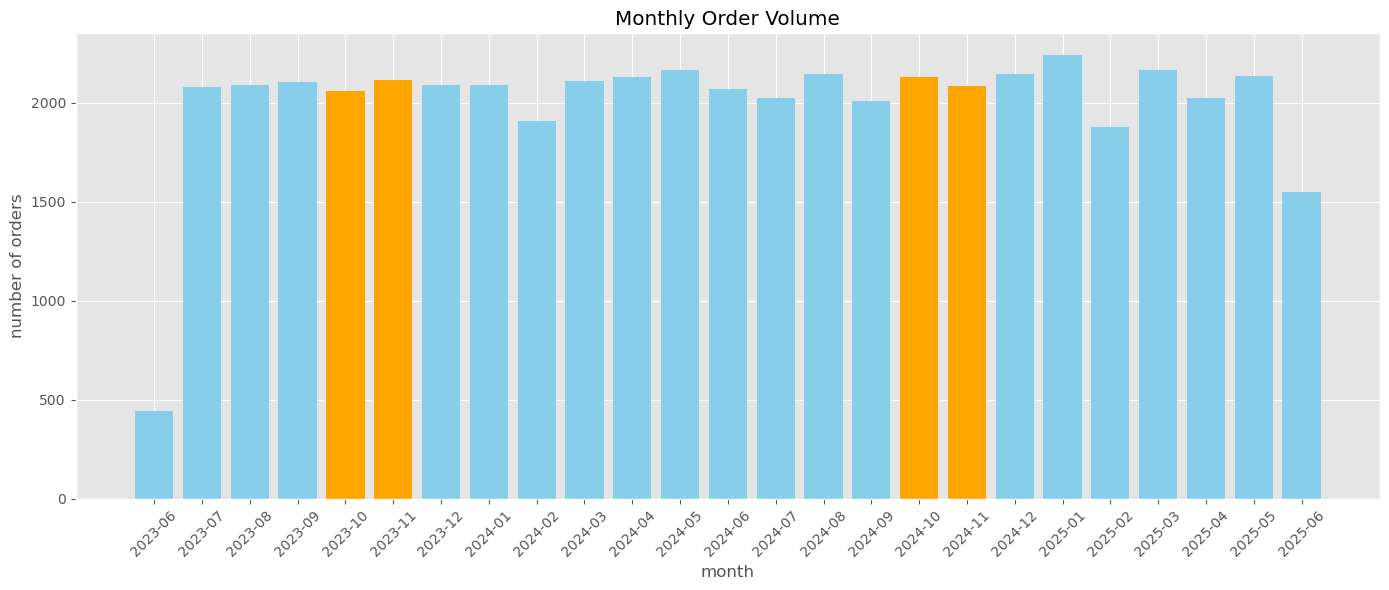

In [95]:
plt.figure(figsize=(14,6))

colors = []

for month in monthly_orders.index:
    if month.endswith("-10") or month.endswith("-11"):
        colors.append("orange")
    else:
        colors.append("skyblue")

plt.bar(monthly_orders.index, monthly_orders.values, color=colors)

plt.title("Monthly Order Volume")
plt.xlabel("month")
plt.ylabel("number of orders")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("01_Monthly_Order_Volume.png", dpi=300, bbox_inches="tight")
plt.show()

In [96]:
orders['order_date'] = pd.to_datetime(orders['order_date'])

orders['Year'] = orders['order_date'].dt.year
orders['Month'] = orders['order_date'].dt.strftime('%b')

In [97]:
monthly_revenue = orders.pivot_table(
    values='final_amount',
    index='Month',
    columns='Year',
    aggfunc='sum'
)

month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

monthly_revenue = monthly_revenue.reindex(month_order)

monthly_revenue

Year,2023,2024,2025
Month,,,
Jan,NaN,1.314500e+08,1.379291e+08
Feb,NaN,1.209459e+08,1.141167e+08
Mar,NaN,1.336701e+08,1.364932e+08
Apr,NaN,1.315097e+08,1.308222e+08
May,NaN,1.363584e+08,1.358494e+08
Jun,2.738485e+07,1.237410e+08,1.036033e+08
Jul,1.289205e+08,1.270283e+08,NaN
Aug,1.281220e+08,1.319235e+08,NaN
Sep,1.374625e+08,1.305253e+08,NaN


<Figure size 1200x600 with 0 Axes>

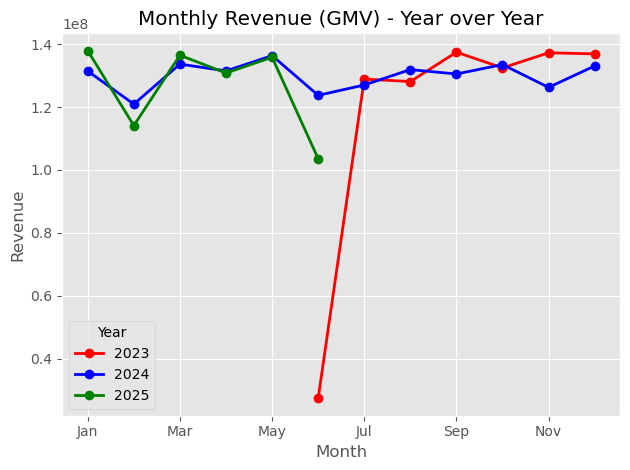

In [98]:
plt.figure(figsize=(12,6))

monthly_revenue.plot(
    marker='o',
    linewidth=2,
    color=['red', 'blue', 'green']
)

plt.title("Monthly Revenue (GMV) - Year over Year")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.legend(title="Year")
plt.grid(True)

plt.tight_layout()
plt.savefig("02_Monthly_Revenue_GMV.png", dpi=300, bbox_inches="tight")
plt.show()

In [99]:
### Observation

# - Revenue remained relatively stable across most months.
# - October and November show strong revenue due to the Diwali shopping season.
# - 2023 starts from June and 2025 ends at June, so those years have partial data.

In [100]:
merged_data = order_items.merge(
    products[['product_id', 'category']],
    on='product_id',
    how='left'
)

merged_data = merged_data.merge(
    orders[['order_id', 'final_amount']],
    on='order_id',
    how='left'
)

category_revenue = merged_data.groupby('category_x')['final_amount'].sum().sort_values(ascending=False)

category_revenue

category_x
Electronics         2.209241e+09
Sports & Fitness    1.050997e+09
Home & Kitchen      8.278370e+08
Fashion             7.210428e+08
Automotive          7.016790e+08
Office Supplies     6.811796e+08
Toys & Baby         6.317914e+08
Beauty & Health     6.046127e+08
Grocery             5.979164e+08
Books               5.866040e+08
Name: final_amount, dtype: float64

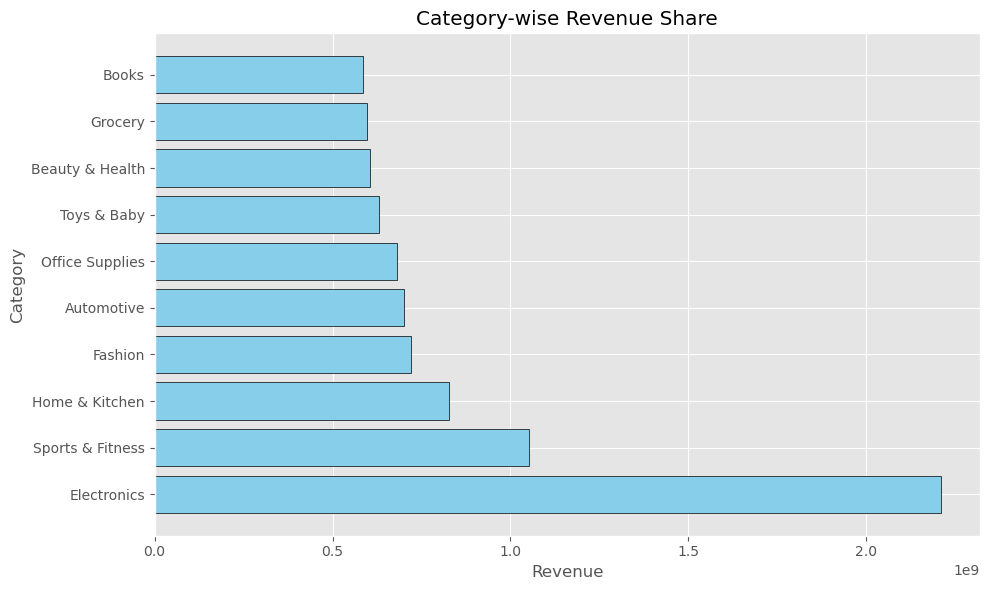

In [101]:
plt.figure(figsize=(10,6))

plt.barh(category_revenue.index,category_revenue.values,color="skyblue",edgecolor="black")

plt.title("Category-wise Revenue Share")
plt.xlabel("Revenue")
plt.ylabel("Category")

plt.tight_layout()
plt.savefig("03_Category_Revenue_Share.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
### Observation

- Electronics generated the highest revenue among all product categories.
- Sports & Fitness is the second highest revenue-generating category.
- Books generated the lowest revenue among all categories.

In [104]:
status_count = orders['status'].value_counts()

status_count

status
Delivered     32499
Cancelled      5996
Shipped        5071
Returned       3933
Processing     2501
Name: count, dtype: int64

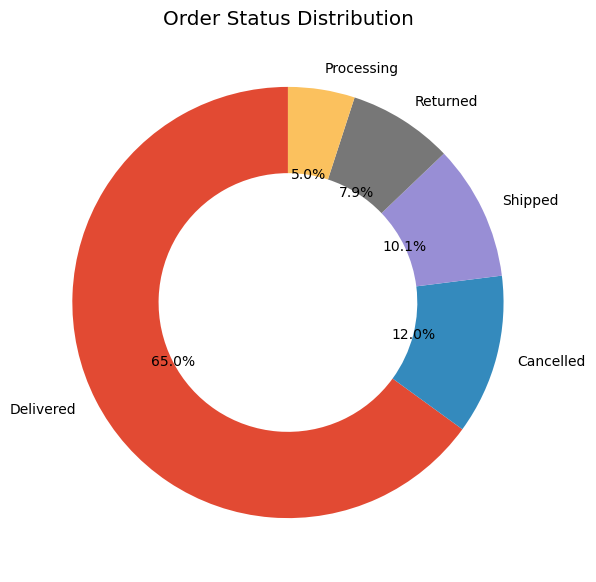

In [105]:
plt.figure(figsize=(7,7))

plt.pie(
    status_count,labels=status_count.index,autopct='%1.1f%%',startangle=90,wedgeprops=dict(width=0.4)
)

plt.title("Order Status Distribution")
plt.savefig("04_Order_Status_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
### Observation

- Delivered orders account for the highest share (around 65%) of total orders.
- Cancelled and Shipped orders together contribute a much smaller share than Delivered orders.
- Returned and Processing orders have the lowest percentage among all order statuses.

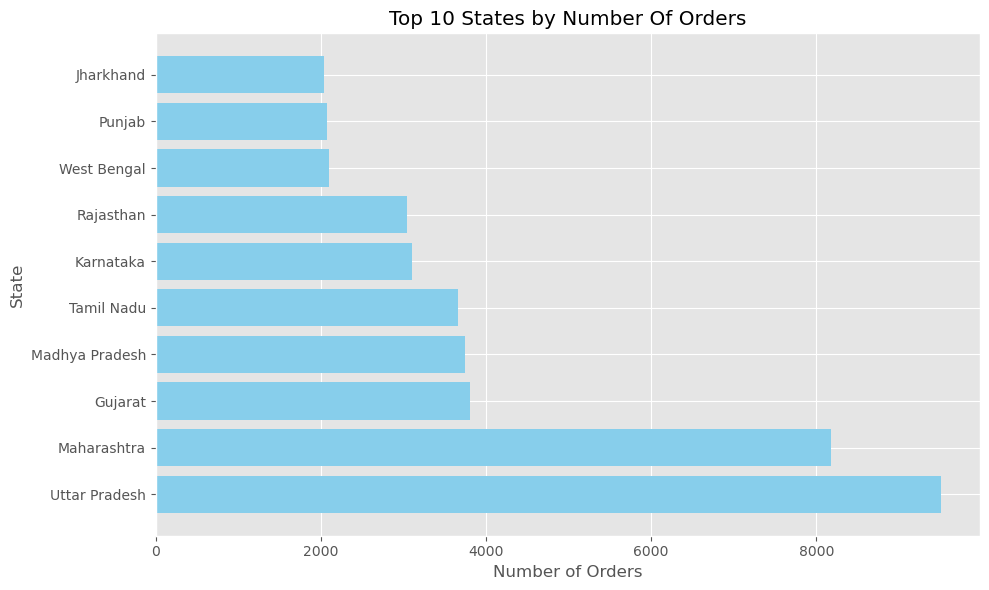

In [106]:
state_orders = orders['state'].value_counts().head(10)

plt.figure(figsize=(10,6))
plt.barh(state_orders.index, state_orders.values, color='skyblue')

plt.title("Top 10 States by Number Of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("State")

plt.tight_layout()
plt.savefig("05_Top10_States.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
### Observation

- Uttar Pradesh has the highest number of orders among all states.
- Maharashtra is the second-highest state in terms of order volume.
- Jharkhand has the lowest number of orders among the top 10 states.

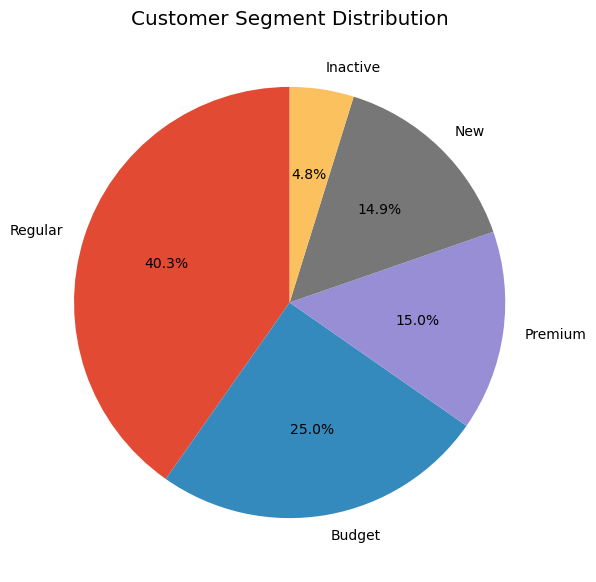

In [107]:
segment_count = customers['segment'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    segment_count,
    labels=segment_count.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Customer Segment Distribution")
plt.savefig("06_Customer_Segment_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
### Observation

- Regular customers form the largest customer segment (40.3%).
- Budget customers are the second-largest segment (25.0%).
- Premium and New customers contribute nearly equal shares (15.0% and 14.9%).
- Inactive customers make up the smallest segment (4.8%).

In [108]:
payment_count = orders['payment_method'].value_counts()

payment_count

payment_method
UPI                 17570
Credit Card         10007
Debit Card           7624
Cash on Delivery     5883
Net Banking          4026
EMI                  2943
Wallet               1947
Name: count, dtype: int64

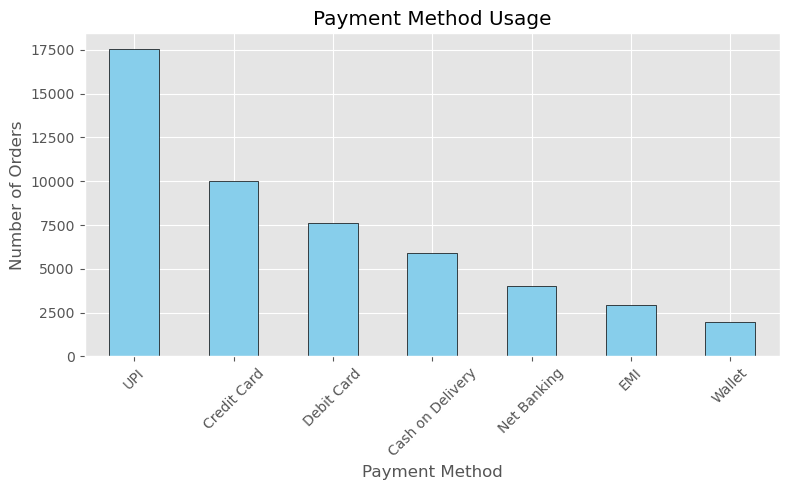

In [109]:
plt.figure(figsize=(8,5))

payment_count.plot(
    kind='bar',
    color='skyblue',
    edgecolor='black'
)

plt.title("Payment Method Usage")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("07_Payment_Method_Usage.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
### Observation

# - UPI is the most preferred payment method, accounting for the highest number of orders.
# - Credit Card and Debit Card are the second and third most popular payment methods.
# - Wallet is the least used payment method among customers.

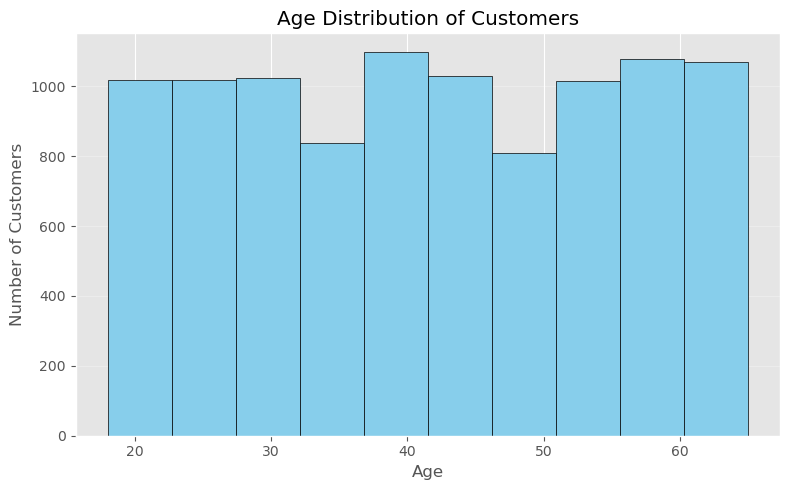

In [110]:
plt.figure(figsize=(8,5))

plt.hist(
    customers['age'],
    bins=10,
    color='skyblue',
    edgecolor='black'
)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("08_Age_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
### Observation

# - Most customers belong to the age group of approximately 20–45 years.
# - Customer count gradually decreases for higher age groups.
# - Middle-aged customers contribute the largest share of the customer base.

In [111]:
reason_count = returns['reason'].value_counts()

reason_count

reason
Size Issue                 1196
Changed Mind               1150
Damaged in Transit         1143
Wrong Product Delivered    1135
Defective Product          1134
Not as Described           1125
Duplicate Order            1081
Quality Issue              1075
Delayed Delivery            484
Better Price Found          477
Name: count, dtype: int64

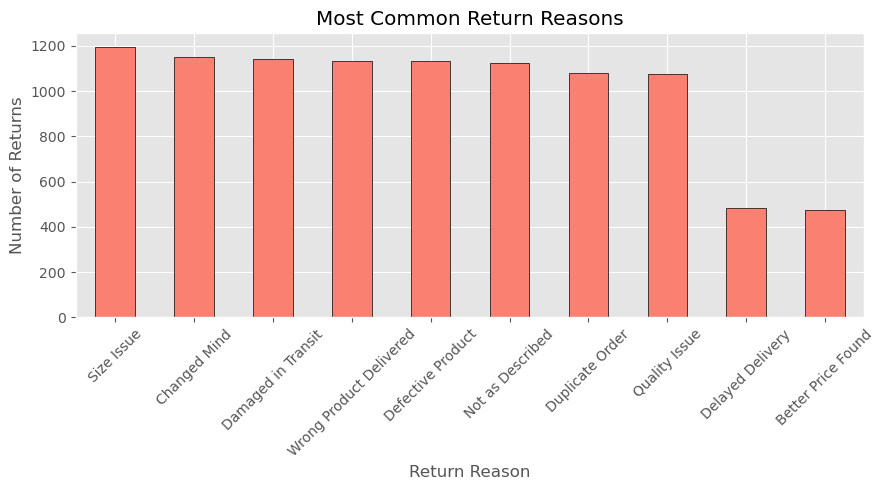

In [112]:
plt.figure(figsize=(9,5))

reason_count.plot(
    kind='bar',
    color='salmon',
    edgecolor='black'
)

plt.title("Most Common Return Reasons")
plt.xlabel("Return Reason")
plt.ylabel("Number of Returns")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("09_Return_Reasons.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
### Observation

# - Size Issue is the most common reason for product returns.
# - Better Price Found and Delayed Delivery are the least common return reasons.
# - Most return reasons have similar frequencies, indicating that returns are caused by multiple factors.

In [113]:
merged_orders = orders.merge(
    customers[['customer_id', 'segment']],
    on='customer_id',
    how='left'
)

merged_orders.head()

,order_id,customer_id,order_date,order_time,status,city,state,pincode,total_amount,gst_amount,...,final_amount,payment_method,shipping_partner,tracking_id,delivered_date,is_cod,channel,Year,Month,segment
0,ORD000001,CUST02946,2025-05-22,17:10:00,Processing,Pune,Maharashtra,300862,100984.19,16364.64,...,100984.19,Cash on Delivery,BlueDart,TRK354572763,NaN,1,App,2025,May,Budget
1,ORD000002,CUST04232,2023-10-16,05:32:00,Delivered,Ludhiana,Punjab,387852,254478.01,41599.80,...,254478.01,UPI,DTDC,TRK272838570,2023-10-19,0,Website,2023,Oct,Inactive
2,ORD000003,CUST08078,2023-10-08,12:32:00,Cancelled,Meerut,Uttar Pradesh,294014,32557.06,3562.92,...,32557.06,Debit Card,Amazon Logistics,TRK338505401,NaN,0,App,2023,Oct,Regular
3,ORD000004,CUST09612,2023-10-02,08:05:00,Delivered,Nashik,Maharashtra,626047,24836.94,3092.88,...,24836.94,UPI,DTDC,TRK289792017,2023-10-09,0,Mobile Web,2023,Oct,New
4,ORD000005,CUST03065,2024-06-15,20:19:00,Delivered,Moradabad,Uttar Pradesh,409210,156689.29,25092.36,...,156689.29,UPI,Ecom Express,TRK978240041,2024-06-22,0,App,2024,Jun,Regular


In [114]:
aov_by_segment = merged_orders.groupby('segment')['final_amount'].mean().sort_values(ascending=False)

aov_by_segment

segment
Budget      64124.558428
New         63381.577666
Regular     63123.549510
Premium     61876.903871
Inactive    57120.144096
Name: final_amount, dtype: float64

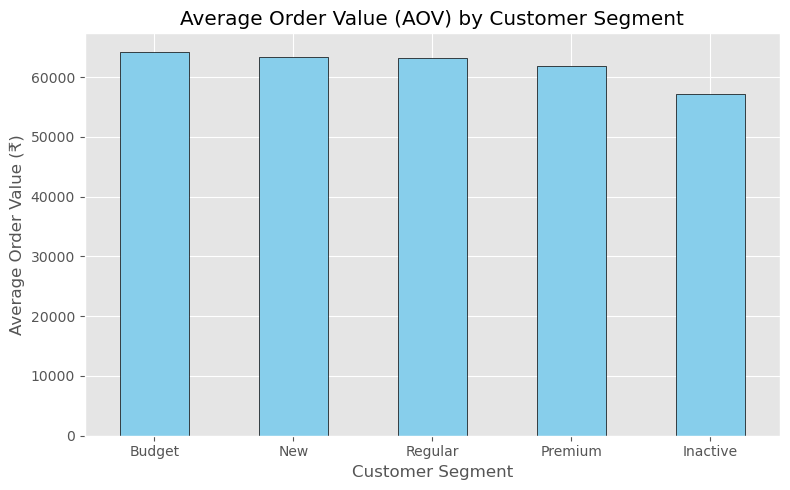

In [115]:
plt.figure(figsize=(8,5))

aov_by_segment.plot(
    kind='bar',
    color='skyblue',
    edgecolor='black'
)

plt.title("Average Order Value (AOV) by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Order Value (₹)")

plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("10_AOV_by_Segment.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
### Observation

# - Budget customers have the highest Average Order Value (AOV), indicating they spend the most per order.
# - New and Regular customers also show relatively high AOV, with only a small difference between them.
# - Inactive customers have the lowest Average Order Value among all customer segments.